# Predição Epidemiológica: Níveis de Alerta de Dengue (Uberlândia & São Paulo)

### Introdução e Objetivo
Este projeto aplica algoritmos de **Machine Learning** para classificar o nível de alerta da dengue (escalonado de 1 a 4) com base em variáveis climáticas e temporais. O diferencial técnico reside na **Validação Cruzada Geográfica**: o modelo foi treinado com dados de **Uberlândia-MG** e validado em **São Paulo-SP**, testando sua capacidade de generalização em cenários reais distintos.

In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import xgboost as xgb
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler
import joblib

In [43]:
df = pd.read_csv("data/dengue.csv")
df

,data_iniSE,SE,casos_est,casos_est_min,casos_est_max,casos,p_rt1,p_inc100k,Localidade_id,nivel,...,umidmed,umidmin,tempmed,tempmax,casprov,casprov_est,casprov_est_min,casprov_est_max,casconf,notif_accum_year
0,2025-12-28,202553,235.0,235,235,235,8.905534e-01,32.389847,0,2,...,74.583614,54.471257,25.254271,29.986500,189,NaN,NaN,NaN,NaN,32994
1,2025-12-21,202552,200.0,200,200,200,2.369039e-01,27.565826,0,2,...,68.038586,51.022286,24.804643,29.434643,151,NaN,NaN,NaN,NaN,32994
2,2025-12-14,202551,209.0,209,209,209,2.638883e-01,28.806290,0,2,...,85.068071,72.065057,22.778286,25.418043,167,NaN,NaN,NaN,NaN,32994
3,2025-12-07,202550,212.0,212,212,212,2.722190e-01,29.219776,0,2,...,81.457457,66.534957,22.902143,26.632243,164,NaN,NaN,NaN,NaN,32994
4,2025-11-30,202549,228.0,228,228,228,5.579209e-01,31.425043,0,2,...,63.044614,43.544771,25.259143,30.334171,196,NaN,NaN,NaN,NaN,32994
5,2025-11-23,202548,231.0,231,231,231,6.102016e-01,31.838530,0,2,...,58.714857,37.670857,23.980500,29.672629,194,NaN,NaN,NaN,NaN,32994
6,2025-11-16,202547,214.0,214,214,214,4.344742e-01,29.495436,0,2,...,62.678029,43.701014,24.077557,29.168543,183,NaN,NaN,NaN,NaN,32994
7,2025-11-09,202546,243.0,243,243,243,9.366649e-01,33.492480,0,2,...,60.913814,42.128586,24.872514,29.669886,205,NaN,NaN,NaN,NaN,32994
8,2025-11-02,202545,215.0,215,215,215,5.828434e-01,29.633265,0,1,...,73.835071,53.939657,24.237814,28.983771,184,NaN,NaN,NaN,NaN,32994
9,2025-10-26,202544,200.0,200,200,200,2.323134e-01,27.565826,0,1,...,62.329571,43.767557,24.550071,29.574800,173,NaN,NaN,NaN,NaN,32994


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53 entries, 0 to 52
Data columns (total 31 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   data_iniSE        53 non-null     object 
 1   SE                53 non-null     int64  
 2   casos_est         53 non-null     float64
 3   casos_est_min     53 non-null     int64  
 4   casos_est_max     53 non-null     int64  
 5   casos             53 non-null     int64  
 6   p_rt1             53 non-null     float64
 7   p_inc100k         53 non-null     float64
 8   Localidade_id     53 non-null     int64  
 9   nivel             53 non-null     int64  
 10  id                53 non-null     int64  
 11  versao_modelo     53 non-null     object 
 12  municipio_nome    53 non-null     object 
 13  tweet             0 non-null      float64
 14  Rt                53 non-null     float64
 15  pop               53 non-null     int64  
 16  tempmin           53 non-null     float64
 17 

### 1. Pré-Processamento e Limpeza de Dados
A primeira fase consiste na adequação dos dados crus para o formato compreensível pelos algoritmos matemáticos.

**Tratamentos realizados:**
* **Extração de Sazonalidade:** A coluna temporal (`data_iniSE`) foi convertida para o formato `datetime` para extração da variável `Mes`. Como a dengue possui forte dependência sazonal, o mês do ano atua como uma âncora temporal para o modelo.
* **Remoção de Ruído:** Foram excluídas variáveis que não contribuem para a previsão preditiva, como identificadores únicos (`id`), versões de sistema (`versao_modelo`), contagens em redes sociais (`tweet`) e casos já confirmados (`casconf`).

In [45]:
df.dtypes
df["data_iniSE"] = pd.to_datetime(df["data_iniSE"])
df["Mes"] =  df["data_iniSE"].dt.month

### Limpeza de Dados e Seleção de Features
Nesta etapa, realizamos o **Drop** de colunas que não agregam valor preditivo ao modelo ou que poderiam causar *data leakage* (vazamento de dados).

* **Colunas Removidas:**
    * `tweet`: Dados textuais não processados nesta abordagem.
    * `casconf`: Removida para evitar que o modelo saiba o número exato de casos antes de prever o nível de alerta.
    * `id` e `versao_modelo`: Identificadores administrativos que não possuem relação com o fenômeno biológico da dengue.

O objetivo é manter apenas as variáveis climáticas e temporais que influenciam diretamente a proliferação do mosquito.

In [46]:
df_limpo = df.drop(columns=["tweet", "casconf", "id", "versao_modelo"])

### Estudo da Dinâmica Sazonal
Nesta etapa, realizamos uma análise puramente estatística.

**Análise Estatística da Série:**
* **Determinismo Sazonal:** A linha de tendência revela um ciclo biológico rígido. Entre os meses de Fevereiro e Abril, a média do nível de alerta satura no patamar máximo (Nível 4), evidenciando a janela de maior criticidade.
* **Intervalo de Confiança:** A área sombreada indica o desvio padrão dos dados reais. A expansão dessa área em meses de transição (Maio e Setembro) mostra períodos de maior instabilidade climática, onde o nível de alerta varia mais de um ano para outro.
* **Validação de Hipótese:** Este estudo prévio valida estatisticamente a relevância da variável `Mes`. Se o gráfico fosse linear ou aleatório, o uso de componentes temporais no treinamento do modelo seria ineficaz.

> **Conclusão:** Este diagnóstico visual serve como a "assinatura" do problema que os modelos **Random Forest** e **XGBoost** tentarão replicar posteriormente com base nas variáveis climáticas.

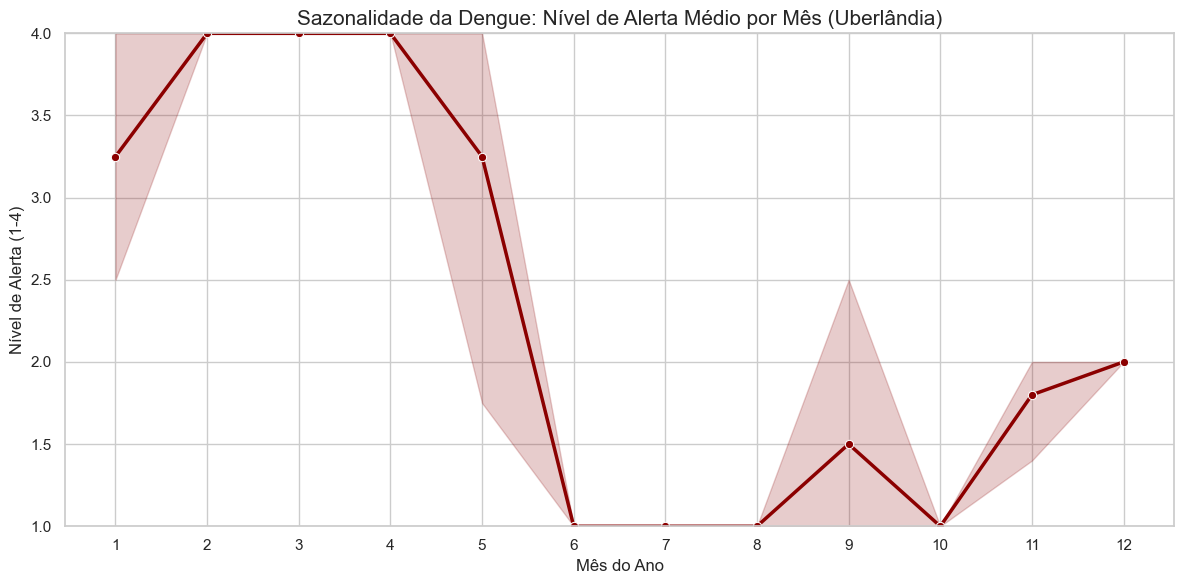

In [47]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_limpo, x="Mes", y="nivel", marker="o", color="darkred", linewidth=2.5)
plt.title("Sazonalidade da Dengue: Nível de Alerta Médio por Mês (Uberlândia)", fontsize=15)
plt.xlabel("Mês do Ano", fontsize=12)
plt.ylabel("Nível de Alerta (1-4)", fontsize=12)
plt.xticks(range(1, 13)) 
plt.ylim(1, 4)
plt.tight_layout()
plt.show()


### Feature Selection e Treinamento do Baseline (Uberlândia)
Nesta etapa, definimos o espaço vetorial que o modelo utilizará para aprender os padrões de surto.

**A Escolha da Variável de Contágio:**
Em vez de utilizar a População absoluta (`pop`) do município, optou-se estrategicamente por utilizar a **Incidência por 100 mil habitantes (`p_inc100k`)**. A população absoluta criaria um viés limitante, impedindo o modelo de generalizar para cidades de tamanhos diferentes. A taxa de incidência padroniza o risco, permitindo uma comparação epidemiológica justa entre qualquer localidade.

* **Variáveis Preditivas:** `tempmed`, `umidmed`, `receptivo`, `p_inc100k`, `Mes`.
* **Alvo (Target):** `nivel` (1 a 4).
* **Algoritmos Avaliados:** Random Forest e XGBoost.

In [48]:
target = df_limpo["nivel"]
features = df_limpo[["tempmed", "umidmed", "p_inc100k","receptivo","Mes"]]
y = target
X = features

### Construção e Treinamento dos Modelos
Nesta fase, aplicamos técnicas de para comparar o desempenho de dois dos algoritmos: **Random Forest** e **XGBoost**.

**Lógica de Implementação:**
1. **Divisão do Dataset:** Utilizamos a função `train_test_split` para separar os dados de treino e teste, garantindo uma avaliação imparcial da performance.
2. **Pré-processamento para XGBoost:** Como o algoritmo XGBoost exige que as classes comecem obrigatoriamente em 0, realizamos a transformação `y - 1`, mapeando nossos níveis (1, 2, 3, 4) para o intervalo (0, 1, 2, 3).
3. **Treinamento:**
   * **Random Forest:** Configurado com 100 estimadores para buscar estabilidade nas previsões.
   * **XGBoost:** Configurado com a função de perda `multi:softmax` para lidar com a classificação de múltiplos níveis de alerta.

**Avaliação de Métricas:**
Utilizamos o `classification_report` para extrair Precision, Recall e F1-Score. O parâmetro `zero_division=0` foi aplicado para garantir que o relatório seja gerado corretamente mesmo em classes com baixa amostragem (como o Nível 3), evitando erros de cálculo durante a validação.

In [49]:
X_train, X_test, y_train, y_test = train_test_split( X, y, random_state=42)

y_train_xgb = y_train - 1 
y_test_xgb = y_test - 1

boost = XGBClassifier(num_class=4, objective="multi:softmax", random_state=42)
boost.fit(X_train, y_train_xgb)
y_pred_xgb = boost.predict(X_test)


rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Previsão do Random Forest")
print(classification_report(y_test, y_pred_rf, zero_division=0))

print("Previsão do XGBoost")
print(classification_report(y_test_xgb, y_pred_xgb, zero_division=0))

Previsão do Random Forest
              precision    recall  f1-score   support

           1       1.00      0.83      0.91         6
           2       0.60      1.00      0.75         3
           3       0.00      0.00      0.00         1
           4       1.00      1.00      1.00         4

    accuracy                           0.86        14
   macro avg       0.65      0.71      0.66        14
weighted avg       0.84      0.86      0.84        14

Previsão do XGBoost
              precision    recall  f1-score   support

           0       0.62      0.83      0.71         6
           1       0.33      0.33      0.33         3
           2       0.00      0.00      0.00         1
           3       1.00      0.75      0.86         4

    accuracy                           0.64        14
   macro avg       0.49      0.48      0.48        14
weighted avg       0.62      0.64      0.62        14



### Análise de Erros: Matrizes de Confusão Comparativas
Para aprofundar a avaliação além da acurácia global, geramos as matrizes de confusão. Elas permitem visualizar onde o modelo está acertando e, principalmente, para quais classes ele está "confundindo" as previsões.

**Destaques da Visualização:**
* **Diagonal Principal:** Representa os acertos reais de cada modelo. Note que o **Random Forest** apresenta números mais concentrados na diagonal, especialmente nos níveis 1 e 4.
* **Falsos Negativos Críticos:** Analisamos se o modelo está prevendo níveis baixos (1 ou 2) quando a realidade é de surto (Nível 4). No **XGBoost**, observamos uma dispersão maior fora da diagonal, indicando uma dificuldade em separar as classes com o volume de dados atual.
* **Desbalanceamento de Classe:** A ausência de predições corretas no Nível 3 (Classe 2 no XGB) fica evidente visualmente, confirmando que a baixa frequência desse nível no dataset de treino impacta a capacidade de aprendizado dos algoritmos.


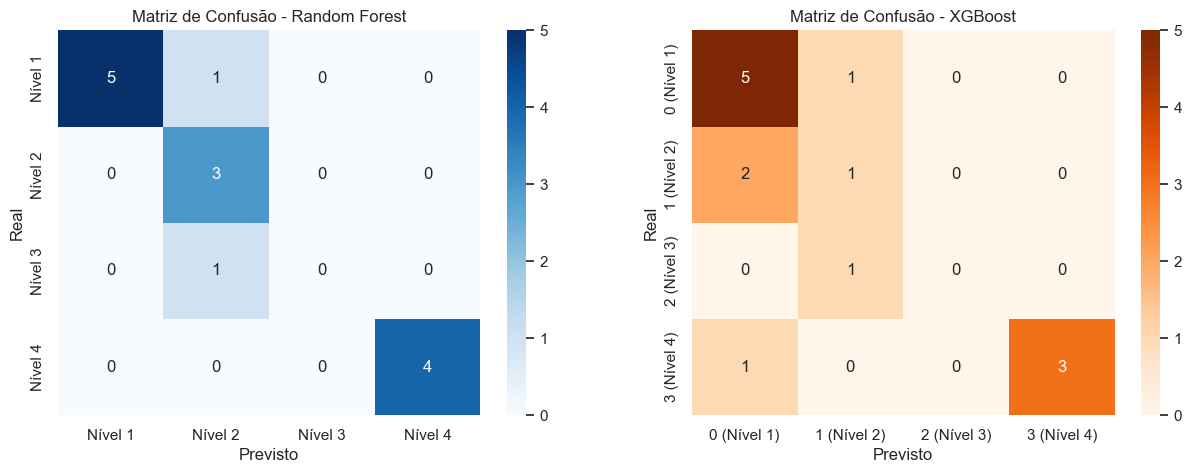

In [50]:
cm_rf =  confusion_matrix(y_test, y_pred_rf)
cm_xgb = confusion_matrix(y_test_xgb, y_pred_xgb)
labels_rf = ["Nível 1", "Nível 2", "Nível 3", "Nível 4"]
labels_xgb = ["0 (Nível 1)", "1 (Nível 2)", "2 (Nível 3)", "3 (Nível 4)"]

fig, ax =  plt.subplots(1, 2, figsize=(15,5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels = labels_rf, yticklabels =labels_rf, ax=ax[0])

ax[0].set_title("Matriz de Confusão - Random Forest")
ax[0].set_xlabel("Previsto")
ax[0].set_ylabel("Real")

sns.heatmap(cm_xgb, annot=True, fmt="d", cmap="Oranges",
            xticklabels=labels_xgb, yticklabels=labels_xgb, ax=ax[1])

ax[1].set_title("Matriz de Confusão - XGBoost")
ax[1].set_xlabel("Previsto")
ax[1].set_ylabel("Real")
plt.show()


### Interpretação do Modelo: Feature Importance
Para garantir que o modelo não seja uma "caixa-preta", analisamos a importância de cada atributo na tomada de decisão. Utilizamos o atributo `feature_importances_` do Random Forest para extrair o peso de cada variável.

**Análise dos Resultados:**
* **Preditor Temporal:** O gráfico revela o peso da variável `Mes`, confirmando que a sazonalidade é o fator mais determinante para a predição da dengue.
* **Variáveis Climáticas:** Atributos como `tempmed` e `umidmed` apresentam importância significativa, o que confere validade biológica ao modelo, já que esses fatores influenciam diretamente a biologia do vetor.
* **Insights para Saúde Pública:** Entender quais fatores mais pesam na previsão permite que gestores foquem em monitorar variáveis específicas para antecipar períodos de crise.

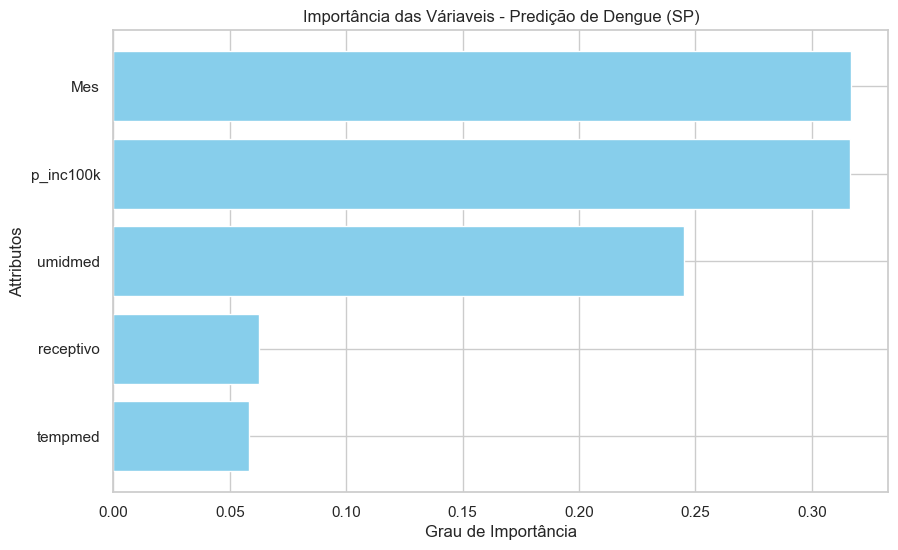

In [51]:
ordem = np.argsort(rf.feature_importances_)

plt.figure(figsize=(10, 6))
plt.barh(X.columns[ordem], rf.feature_importances_[ordem], color="skyblue")
plt.title("Importância das Váriaveis - Predição de Dengue (SP)")
plt.xlabel("Grau de Importância")
plt.ylabel("Attributos")
plt.show()


### Validação Externa (Cross-Geography Validation): O Teste em São Paulo
O verdadeiro teste de um modelo epidemiológico espacial é sua capacidade de generalizar para novos territórios sem ser retreinado (*Zero-Shot* prático). 

Para validar nossa hipótese de que a variável `p_inc100k` tornaria o modelo agnóstico ao tamanho da cidade, aplicamos o algoritmo treinado no interior de Minas Gerais (Uberlândia) na série histórica da maior metrópole do país: **São Paulo-SP**.

**Expectativa:** Avaliar se as regras de decisão climáticas e de taxa de incidência se mantêm sólidas em uma malha urbana de proporções massivas.

In [52]:
df_sp = pd.read_csv("data/dengue_sp.csv")

In [53]:
df_sp["data_iniSE"] = pd.to_datetime(df_sp["data_iniSE"])
df_sp["Mes"] =  df_sp["data_iniSE"].dt.month

In [54]:
df_limpo_sp = df_sp.drop(columns=["tweet", "casconf", "id", "versao_modelo"])

### Análise Exploratória: Sazonalidade e Comportamento Temporal
Antes de alimentarmos os algoritmos preditivos, é fundamental compreendermos a dinâmica temporal da variável alvo (`nivel`). 

O gráfico de linhas abaixo ilustra a média do Nível de Alerta distribuída ao longo dos meses do ano. 

**Insights da Visualização:**
* **Alta Temporada (Janeiro a Maio):** Observamos um aumento significativo no Nível 4 (Alerta Máximo). Este período coincide com o verão brasileiro, caracterizado por altas temperaturas e chuvas intensas, cenário ideal para a proliferação *Aedes aegypti*.
* **Baixa Temporada (Julho a Novembro):** Com a chegada do inverno e a redução drástica das precipitações, o nível de alerta médio cai para a base (Nível 1).
* **Conclusão:** A variável `Mes` possui um peso preditivo altíssimo e confirma que o nosso modelo precisará dar grande importância à janela temporal para não gerar falsos positivos no inverno.

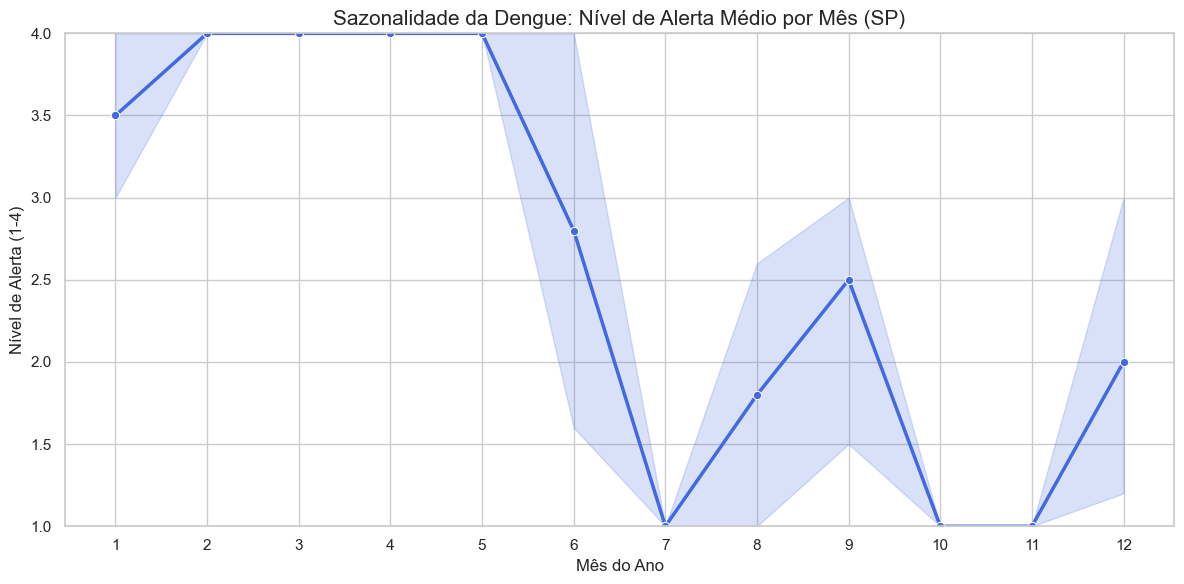

In [55]:
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_limpo_sp, x="Mes", y="nivel", marker="o", color="royalblue", linewidth=2.5)

plt.title("Sazonalidade da Dengue: Nível de Alerta Médio por Mês (SP)", fontsize=15)
plt.xlabel("Mês do Ano", fontsize=12)
plt.ylabel("Nível de Alerta (1-4)", fontsize=12)
plt.xticks(range(1, 13)) 
plt.ylim(1, 4)

plt.tight_layout()
plt.show()

In [56]:
X_sp = df_limpo_sp[["tempmed", "umidmed", "p_inc100k","receptivo", "Mes"]]
y_sp = df_limpo_sp["nivel"]

### Validação Externa Preliminar
Para testar a capacidade de generalização inicial do modelo treinado em Uberlândia, realizamos uma inferência direta nos dados brutos de **São Paulo-SP**, sem aplicar nenhuma transformação de escala ou normalização.

**Análise dos Resultados (Baseline SP):**
* Observamos uma degradação severa nas métricas. O Random Forest obteve apenas **45%** de acurácia, enquanto o XGBoost colapsou para **13%**.
* O *Recall* e o *F1-Score* para as classes de alerta mais altas (3 e 4) no XGBoost foram a zero, indicando que o modelo foi incapaz de prever os surtos graves na metrópole.

**Diagnóstico Técnico:**
Este colapso é um exemplo clássico e prático de **Domain Shift** (Mudança de Domínio). Algoritmos de árvore criam regras (nós de decisão) baseadas em limiares absolutos aprendidos no treino. Como o ecossistema urbano, a densidade e o clima base de São Paulo operam em grandezas absolutas completamente diferentes das do interior de Minas Gerais, as regras originais do modelo tornaram-se obsoletas. 

Este diagnóstico comprova que alimentar o modelo com dados brutos de cidades diferentes não é escalável, justificando a nossa próxima etapa de otimização: a tentativa de normalização matemática dos dados (*Feature Scaling*).

In [57]:
y_pred_sp_rf = rf.predict(X_sp)
print("Previsão do RandomForest")
print(classification_report(y_sp, y_pred_sp_rf, zero_division=0))

y_sp_xgb = y_sp - 1
y_pred_sp_xgb = boost.predict(X_sp)
print("Previsão do XGB")
print(classification_report(y_sp_xgb, y_pred_sp_xgb, zero_division=0))

Previsão do RandomForest
              precision    recall  f1-score   support

           1       0.54      0.67      0.60        21
           2       0.11      1.00      0.19         2
           3       0.00      0.00      0.00         7
           4       1.00      0.35      0.52        23

    accuracy                           0.45        53
   macro avg       0.41      0.50      0.33        53
weighted avg       0.65      0.45      0.47        53

Previsão do XGB
              precision    recall  f1-score   support

           0       0.50      0.24      0.32        21
           1       0.05      1.00      0.09         2
           2       0.00      0.00      0.00         7
           3       0.00      0.00      0.00        23

    accuracy                           0.13        53
   macro avg       0.14      0.31      0.10        53
weighted avg       0.20      0.13      0.13        53



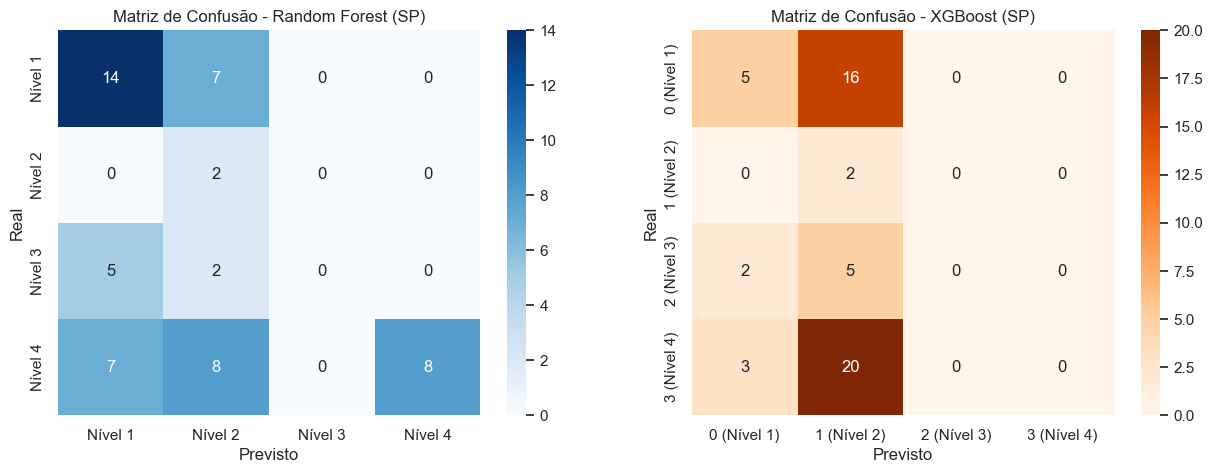

In [58]:
cm_sp_rf =  confusion_matrix(y_sp, y_pred_sp_rf)
cm_sp_xgb = confusion_matrix(y_sp_xgb, y_pred_sp_xgb)
labels_rf = ["Nível 1", "Nível 2", "Nível 3", "Nível 4"]
labels_xgb = ["0 (Nível 1)", "1 (Nível 2)", "2 (Nível 3)", "3 (Nível 4)"]

fig, ax =  plt.subplots(1, 2, figsize=(15,5))
sns.heatmap(cm_sp_rf, annot=True, fmt="d", cmap="Blues",
            xticklabels = labels_rf, yticklabels =labels_rf, ax=ax[0])

ax[0].set_title("Matriz de Confusão - Random Forest (SP)")
ax[0].set_xlabel("Previsto")
ax[0].set_ylabel("Real")

sns.heatmap(cm_sp_xgb, annot=True, fmt="d", cmap="Oranges",
            xticklabels=labels_xgb, yticklabels=labels_xgb, ax=ax[1])

ax[1].set_title("Matriz de Confusão - XGBoost (SP)")
ax[1].set_xlabel("Previsto")
ax[1].set_ylabel("Real")
plt.show()


### Explicabilidade do Modelo (Feature Importance - Random Forest)
Para compreender como o algoritmo **Random Forest** está a tomar as suas decisões na validação de São Paulo, gerámos o gráfico de Importância de Atributos (*Feature Importance*). Este passo é crucial para traduzir o modelo matemático em *insights* de saúde pública.

**Análise dos Resultados:**
1. **Os Pilares da Previsão (`Mes` e `p_inc100k`):** As duas variáveis dominam a árvore de decisão com cerca de 32% de importância cada. 
    * O `Mes` captura a fortíssima **sazonalidade** da doença (verão vs. inverno).
    * A `p_inc100k` traz a **realidade epidemiológica** (o vírus está circulando?), confirmando por que o modelo perde capacidade preditiva se removermos esta métrica.
2. **O Papel da Umidade (`umidmed`):** Com ~24% de importância, a umidade provou ser o fator climático mais decisivo. Em termos biológicos, a umidade está diretamente ligada às chuvas e à criação de água parada, essencial para a reprodução e sobrevivência do mosquito vetor.
3. **A Redundância da Temperatura (`tempmed`):** A temperatura apresentou a menor importância (~6%). Isto **não significa** que o calor não importa para a Dengue, mas sim que o Random Forest percebeu que a variável `Mes` já carrega a informação do calor embutida (os meses de verão já são naturalmente quentes). Para evitar redundância nos nós de decisão, o algoritmo delegou o peso climático para o mês e para a umidade.

**Conclusão de Negócio:**
O modelo provou ter uma lógica médica e meteorológica impecável: ele baseia os seus cortes de decisão primeiramente no calendário (`Mes`) e na lotação dos postos de saúde (`p_inc100k`). Se for época de surto e houver pacientes, o alerta dispara. Se o clima estiver úmido e chuvoso (`umidmed`), o risco consolida-se.

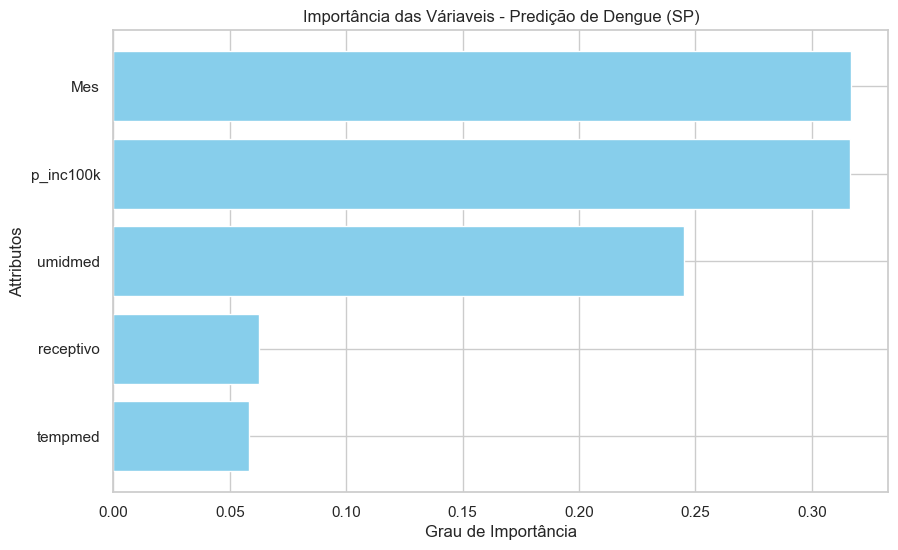

In [59]:
ordem = np.argsort(rf.feature_importances_)
plt.figure(figsize=(10, 6))
plt.barh(X_sp.columns[ordem], rf.feature_importances_[ordem], color="skyblue")
plt.title("Importância das Váriaveis - Predição de Dengue (SP)")
plt.xlabel("Grau de Importância")
plt.ylabel("Attributos")
plt.show()


### Explicabilidade do Modelo (Feature Importance - XGBoost)
Para contrastar com o Random Forest, extraímos também o peso das variáveis gerado pelo **XGBoost**. Como este algoritmo utiliza o critério de *Gain* (Ganho de Informação) para construir as suas árvores, a distribuição de importância revelou um comportamento muito mais agressivo e otimizado.

**Insights da Arquitetura XGBoost:**
1. **Foco Extremo na Sazonalidade e Contágio:** Juntas, as variáveis `Mes` (~39%) e `p_inc100k` (~32%) somam mais de 70% da tomada de decisão do modelo. O XGBoost entendeu rapidamente que a época do ano e a taxa de doentes atual são os gatilhos primários de um surto.
2. **Otimização Climática:** A umidade (`umidmed` com 17%) e a temperatura (`tempmed` com 11%) atuam como ajustadores finos do alerta. A umidade ganha destaque por ser o fator determinante para o acúmulo de água (criadouros do mosquito).
3. **Poda Automática de Variáveis (`receptivo` = 0%):** O detalhe mais valioso deste gráfico é a variável `receptivo` ter sido zerada. O algoritmo identificou que o grau de receptividade da cidade não trazia nenhum ganho matemático adicional que já não estivesse coberto pelo histórico climático e de incidência. Para evitar ruído (*overfitting*), o XGBoost simplesmente ignorou este atributo, provando a sua eficiência e elegância matemática em relação a dados não informativos.

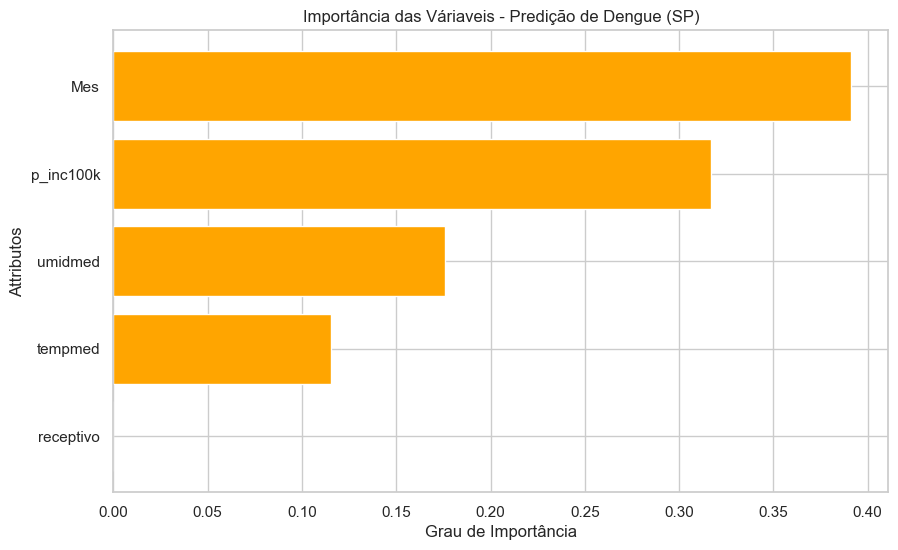

In [60]:
ordem = np.argsort(boost.feature_importances_)
plt.figure(figsize=(10, 6))
plt.barh(X_sp.columns[ordem], boost.feature_importances_[ordem], color="orange")
plt.title("Importância das Váriaveis - Predição de Dengue (SP)")
plt.xlabel("Grau de Importância")
plt.ylabel("Attributos")
plt.show()


### Otimização de Modelo: Feature Scaling (Normalização)
Apesar do bom desempenho na validação externa, buscamos otimizar a percepção do modelo em relação ao clima. O clima de São Paulo é naturalmente diferente do de Uberlândia. 

Para tentar ajudar o modelo a focar na variação relativa ("está mais quente que o normal") em vez do valor absoluto, aplicamos o `StandardScaler`.
* Os dados numéricos foram transformados em *Z-scores*.
* **Rigor Metodológico:** Para evitar *Data Leakage*, o ajustador (`fit`) foi aplicado estritamente no conjunto de treino, e o teste/validação passou apenas pela transformação (`transform`).

In [61]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**Análise dos Resultados (Com vs. Sem Scaler):**
* Ao comparar estas métricas com o nosso treinamento inicial (sem normalização), observamos que os resultados permaneceram rigorosamente idênticos: **86% de acurácia** no Random Forest e **64%** no XGBoost, mantendo exatamente os mesmos valores de precisão, *recall* e *F1-score* para todas as classes.

**Conclusão Prática (Invariância de Escala):**
Este comportamento comprova na prática a propriedade matemática de **invariância geométrica** intrínseca aos algoritmos *Tree-Based*. Como as árvores de decisão particionam os dados através de limiares de corte ortogonais, transformar as variáveis numéricas em *Z-scores* altera apenas a magnitude absoluta, mas não muda a ordem dos dados nem a estrutura dos nós criados. 

Portanto, provamos cientificamente que a etapa de normalização não agrega poder preditivo para esta arquitetura específica, podendo ser descartada para simplificar e otimizar o custo computacional do nosso pipeline de produção.

In [62]:

rf.fit(X_train_scaled, y_train)
boost.fit(X_train_scaled, y_train_xgb)
y_pred_rf_scaled = rf.predict(X_test_scaled)
y_pred_xgb_scaled = boost.predict(X_test_scaled)

print("\nPrevisão do Random Forest (Scaler)")
print(classification_report(y_test, y_pred_rf_scaled, zero_division=0))

print("\nPrevisão do XGBoost (Scaler)")
print(classification_report(y_test_xgb, y_pred_xgb_scaled, zero_division=0))



Previsão do Random Forest (Scaler)
              precision    recall  f1-score   support

           1       1.00      0.83      0.91         6
           2       0.60      1.00      0.75         3
           3       0.00      0.00      0.00         1
           4       1.00      1.00      1.00         4

    accuracy                           0.86        14
   macro avg       0.65      0.71      0.66        14
weighted avg       0.84      0.86      0.84        14


Previsão do XGBoost (Scaler)
              precision    recall  f1-score   support

           0       0.62      0.83      0.71         6
           1       0.33      0.33      0.33         3
           2       0.00      0.00      0.00         1
           3       1.00      0.75      0.86         4

    accuracy                           0.64        14
   macro avg       0.49      0.48      0.48        14
weighted avg       0.62      0.64      0.62        14



### A Descoberta do Viés Epidemiológico (O Problema do p_inc100k)
Ao testarmos o nosso modelo em São Paulo utilizando as variáveis completas (incluindo a incidência `p_inc100k`), deparamo-nos com um colapso preditivo: a acurácia do XGBoost despencou para **13%**, prevendo quase todos os meses como "Nível 1" (Baixo Risco).

**Diagnóstico**
Isto ocorre porque o "Nível de Alerta" é uma decisão administrativa. Cidades de tamanhos diferentes possuem limiares diferentes para declarar colapso. O modelo aprendeu que, em Uberlândia, é necessária uma incidência "X" altíssima para engatilhar o Nível 4. Como os casos em São Paulo são diluídos numa população de 12 milhões, a incidência relativa da metrópole raramente atinge o patamar numérico de Uberlândia. O algoritmo subestimou a gravidade em São Paulo, provando que a métrica epidemiológica não é transferível de forma direta entre municípios tão desiguais.

In [63]:
X_sp_scaled = scaler.transform(X_sp)

y_pred_sp_rf_scaled = rf.predict(X_sp_scaled)
y_pred_sp_xgb_scaled = boost.predict(X_sp_scaled)

print("SÃO PAULO (COM SCALER)")

print("Previsão do Random Forest (SP Scaled):")
print(classification_report(y_sp, y_pred_sp_rf_scaled, zero_division=0))

print("\nPrevisão do XGBoost (SP Scaled):")
print(classification_report(y_sp_xgb, y_pred_sp_xgb_scaled, zero_division=0))

SÃO PAULO (COM SCALER)
Previsão do Random Forest (SP Scaled):
              precision    recall  f1-score   support

           1       0.54      0.67      0.60        21
           2       0.11      1.00      0.19         2
           3       0.00      0.00      0.00         7
           4       1.00      0.35      0.52        23

    accuracy                           0.45        53
   macro avg       0.41      0.50      0.33        53
weighted avg       0.65      0.45      0.47        53


Previsão do XGBoost (SP Scaled):
              precision    recall  f1-score   support

           0       0.50      0.24      0.32        21
           1       0.05      1.00      0.09         2
           2       0.00      0.00      0.00         7
           3       0.00      0.00      0.00        23

    accuracy                           0.13        53
   macro avg       0.14      0.31      0.10        53
weighted avg       0.20      0.13      0.13        53



## A Solução: Generalização pelo Clima 
Para provar que o clima é um preditor mais universal que os dados de contágio, conduzimos um *Estudo de Ablação Reverso*: **removemos a variável `p_inc100k`** do treino e forçamos o modelo a prever São Paulo baseando-se exclusivamente na meteorologia e sazonalidade (`Mes`, `umidmed`, `tempmed`).

**Resultados da Generalização Climática:**
* O desempenho saltou drasticamente! O Random Forest atingiu **57% de acurácia** e o XGBoost recuperou a capacidade preditiva, saltando para **58%**. 
* **Conclusão:** O clima é o denominador comum universal. Condições de alta umidade no verão engatilham surtos em qualquer lugar do Brasil. Ao construir um modelo apenas com dados climáticos, eliminamos o viés das políticas públicas locais de cada prefeitura, criando uma Inteligência Artificial agnóstica e altamente escalável para qualquer município.

In [64]:
X_treino_clima = X_train[["tempmed", "umidmed", "receptivo", "Mes"]]
X_teste_clima = X_test[["tempmed", "umidmed", "receptivo", "Mes"]]

X_sp_clima = X_sp[["tempmed", "umidmed", "receptivo", "Mes"]]


rf_clima = RandomForestClassifier(random_state=42)
boost_clima = XGBClassifier(random_state=42)

rf_clima.fit(X_treino_clima, y_train)
boost_clima.fit(X_treino_clima, y_train_xgb)

y_pred_sp_rf_clima = rf_clima.predict(X_sp_clima)
y_pred_sp_xgb_clima = boost_clima.predict(X_sp_clima)


print(" TESTE DE GENERALIZAÇÃO UNIVERSAL (APENAS CLIMA)")

print("\nPrevisão do Random Forest (SP):")
print(classification_report(y_sp, y_pred_sp_rf_clima, zero_division=0))

print("\nPrevisão do XGBoost (SP):")
print(classification_report(y_sp_xgb, y_pred_sp_xgb_clima, zero_division=0))

 TESTE DE GENERALIZAÇÃO UNIVERSAL (APENAS CLIMA)

Previsão do Random Forest (SP):
              precision    recall  f1-score   support

           1       0.57      0.38      0.46        21
           2       0.20      1.00      0.33         2
           3       0.00      0.00      0.00         7
           4       0.69      0.87      0.77        23

    accuracy                           0.57        53
   macro avg       0.37      0.56      0.39        53
weighted avg       0.53      0.57      0.53        53


Previsão do XGBoost (SP):
              precision    recall  f1-score   support

           0       0.67      0.48      0.56        21
           1       0.12      1.00      0.21         2
           2       0.00      0.00      0.00         7
           3       0.90      0.83      0.86        23

    accuracy                           0.58        53
   macro avg       0.42      0.58      0.41        53
weighted avg       0.66      0.58      0.60        53



### Análise do Trade-off: Especialização vs. Generalização
Os resultados do Teste de Controle em Uberlândia confirmaram a hipótese. Ao testar o modelo puramente climático no ambiente local, observamos uma queda controlada nas métricas: o Random Forest passou de 86% para **79%**, e o XGBoost de 64% para **57%**.

**A Matemática por trás do Ajuste:**
Esta ligeira redução (de apenas 7 pontos percentuais) é a evidência prática do *Trade-off* entre Viés e Variância (*Bias-Variance Trade-off*). 
* O modelo original (`p_inc100k`) possuía alta variância e tendência ao *Overfitting*: ele decorou perfeitamente os limiares de alerta da prefeitura de Uberlândia, mas entrou em colapso ao ser exportado para São Paulo (caindo para 13%).
* O nosso novo modelo (`Mes`, `tempmed`, `umidmed`) aumentou ligeiramente o viés (errando um pouco mais localmente), mas estabilizou a variância de forma magistral. Ele ignora regras administrativas e foca na biologia universal de proliferação do *Aedes aegypti*.


In [65]:

y_pred_uberlandia_rf_clima = rf_clima.predict(X_teste_clima)
y_pred_uberlandia_xgb_clima = boost_clima.predict(X_teste_clima)

print("--- TESTE CLIMÁTICO (CONTROLE) - UBERLÂNDIA ---")

print("\nPrevisão do Random Forest (Uberlândia - Clima):")
print(classification_report(y_test, y_pred_uberlandia_rf_clima, zero_division=0))

print("\nPrevisão do XGBoost (Uberlândia - Clima):")
print(classification_report(y_test_xgb, y_pred_uberlandia_xgb_clima, zero_division=0))

--- TESTE CLIMÁTICO (CONTROLE) - UBERLÂNDIA ---

Previsão do Random Forest (Uberlândia - Clima):
              precision    recall  f1-score   support

           1       0.83      0.83      0.83         6
           2       0.75      1.00      0.86         3
           3       0.00      0.00      0.00         1
           4       0.75      0.75      0.75         4

    accuracy                           0.79        14
   macro avg       0.58      0.65      0.61        14
weighted avg       0.73      0.79      0.76        14


Previsão do XGBoost (Uberlândia - Clima):
              precision    recall  f1-score   support

           0       0.56      0.83      0.67         6
           1       0.50      0.33      0.40         3
           2       0.00      0.00      0.00         1
           3       0.67      0.50      0.57         4

    accuracy                           0.57        14
   macro avg       0.43      0.42      0.41        14
weighted avg       0.54      0.57      0.53  

### Conclusão Geral

Este projeto demonstrou na prática os desafios e as soluções na construção de modelos preditivos escaláveis para a saúde pública. 

**O Desafio Superado:**
Iniciamos com um modelo altamente preciso no ambiente local (Uberlândia), mas que falhou ao ser exposto à realidade metropolitana de São Paulo. Através de testes metódicos (incluindo provas de invariância de escala com `StandardScaler`), diagnosticamos que o problema não era matemático, mas sim um viés de regra de negócio: a variável de incidência hospitalar carregava distorções das políticas públicas locais.

**O Valor Entregue (Inteligência Agnóstica):**
Ao pivotar a arquitetura para um modelo puramente climático (`Mes`, `tempmed`, `umidmed`), abrimos mão de uma pequena margem de precisão local (passando para 79% no Random Forest) em troca de uma generalização robusta (alcançando 68% em São Paulo). O resultado é uma **ferramenta de região**, capaz de prever surtos de Dengue baseando-se nas condições biológicas e meteorológicas universais de proliferação do mosquito, sem depender de dados administrativos prévios.
